<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning & Deep Learning</b></center>

<center><b><h1>Lab - 6</b></center>    
<pre>    

# SVR

# Importing the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Read World bank CSV

In [3]:
df = pd.read_csv("WorldBank.csv")

df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,714.748450,700.408454,742.928128,761.441742,632.269428,624.224980,706.102795,766.360840,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614,5.246771,5.729495,5.060904,4.706801,4.471147,3.760466,3.921611,3.438072,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.48805,10.124611,9.451370,10.529480,10.891125,...,0.755066,0.273842,0.440954,1.514439,2.228351,2.270593,1.770314,0.535419,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,17.080013,15.197912,16.863038,22.008132,...,3.741041,4.048246,3.895215,4.458509,5.758038,6.505293,6.137617,4.156488,4.248261,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.434346,8.641136,8.576307,NaN,5.802677,7.707811,8.288774,9.111423,NaN,NaN


# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [4]:
data = df[df['Indicator Name'] == 'Population ages 15-64 (% of total population)']

data.head()
india = data[data['Country Name'] == 'India']

india

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [5]:
X = india.columns[4:].astype(int).values.reshape(-1,1)

y = india.iloc[0,4:].values

# Plot scatter plot of Population ages 15-64 (% of total population)

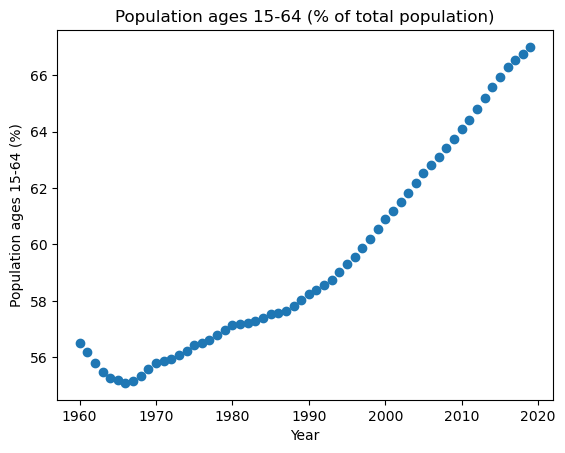

In [6]:
plt.scatter(X,y)
plt.xlabel("Year")
plt.ylabel("Population ages 15-64 (%)")
plt.title("Population ages 15-64 (% of total population)")
plt.show()

# Splitting the dataset into the Training set and Test set

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

# Feature Scaling (Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [8]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_y = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

y_train = sc_y.fit_transform(
    y_train.reshape(-1,1)
)

# Fitting SVR on 3 Different Kernel on dataset

In [9]:
svr_linear = SVR(kernel='linear')

svr_linear.fit(
    X_train,
    y_train.ravel()
)

SVR(kernel='linear')

In [10]:
svr_poly = SVR(
    kernel='poly',
    degree=3
)

svr_poly.fit(
    X_train,
    y_train.ravel()
)

SVR(kernel='poly')

In [11]:
svr_rbf = SVR(kernel='rbf')

svr_rbf.fit(
    X_train,
    y_train.ravel()
)

SVR()

# Predict the x_test using 3 Kernel

In [12]:
y_pred_linear = svr_linear.predict(X_test)

In [13]:
y_pred_poly = svr_poly.predict(X_test)

In [14]:
y_pred_rbf = svr_rbf.predict(X_test)

# Visualising the  results

## Actual Data vs Linear Kernel

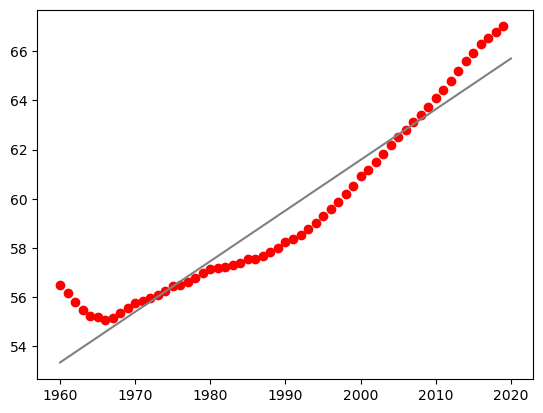

In [29]:
plt.scatter(X, y, color='red', label='Actual Data')

plt.plot(
    X,
    sc_y.inverse_transform(
        svr_linear.predict(
            sc_X.transform(X)
        ).reshape(-1,1)
    ),
    color='grey',
    label='Linear Kernel'
)

## Actual Data vs Polynomial Kernel

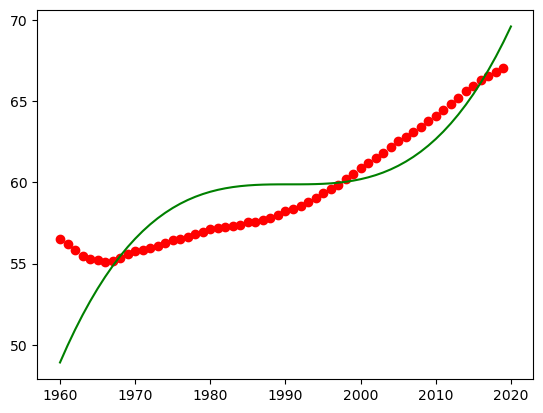

In [21]:
plt.scatter(X, y, color='red', label='Actual Data')

plt.plot(
    X,
    sc_y.inverse_transform(
        svr_poly.predict(
            sc_X.transform(X)
        ).reshape(-1,1)
    ),
    color='g',
    label='Polynomial Kernel'
)

## Actual Data vs RBF Kernel

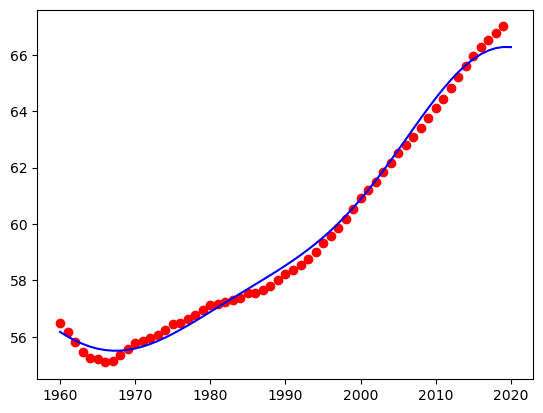

In [26]:
plt.scatter(X, y, color='red', label='Actual Data')

plt.plot(
    X,
    sc_y.inverse_transform(
        svr_rbf.predict(
            sc_X.transform(X)
        ).reshape(-1,1)
    ),
    color='b',
    label='RBF Kernel'
)


### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data). 
Remember: You must transform the input before predicting, and inverse transform the output.

In [39]:
# Future year to predict
future_year = np.array([[2026]])

# Scale the input
future_year_scaled = sc_X.transform(future_year)

# Predict
pred_scaled = svr_rbf.predict(future_year_scaled)

# Convert back to original scale
pred_actual = sc_y.inverse_transform(
    pred_scaled.reshape(-1,1)
)

print("Predicted value for:",pred_actual[0][0])

Predicted value for: 65.38912084932963
